# Examen 3 · Internet de las Cosas: ETL, indicadores, informe y dashboard

**Banda 840–860 MHz · estación móvil de monitoreo · occidente de Medellín**

Este notebook combina en un solo flujo las tres partes del examen:
1. **ETL y calidad de datos** — extracción, validación, imputación, reporte de calidad, ruta e incidencia de la temperatura.
2. **Indicadores e informe técnico** — indicadores por canal, dictamen técnico y (bonificación) estimación de la fuente por canal.
3. **Dashboard interactivo** — servidor Dash + Plotly con mapas de calor y ruta.

Salidas (en `IoT_Examen3/salida/`): `medidas_limpias.csv`, `espectros.npz`, `calidad.json`, `informe_tecnico.md/.html`, `resumen_canales.csv`, `indicadores_medidas.csv`, `fuentes.csv` y figuras.

**Antes de correr:** sube `/Examen_03_2026_20_medidas` a la carpeta `MyDrive/IoT_Examen3/` y ejecuta las celdas en orden.

---
## Parte 1/3 — ETL y calidad de datos


In [30]:
import os, glob, re, json, zipfile, warnings, datetime as dt, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from scipy.ndimage import median_filter
warnings.filterwarnings('ignore')

# Drive en Colab; carpeta local si se ejecuta fuera de Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE, EN_COLAB = '/content/drive/MyDrive/IoT_Examen3', True
except ImportError:
    BASE, EN_COLAB = os.path.abspath('./IoT_Examen3'), False
RAW, OUT = f'{BASE}/raw', f'{BASE}/salida'
FIGS = f'{OUT}/figs'
for d in (RAW, OUT, FIGS): os.makedirs(d, exist_ok=True)

# Parámetros del sensor (tomados de medir_celular.py: USRP, fc=850 MHz, fs=20 MHz, FFT=1024 + fftshift)
FC_MHZ, FS_MHZ, NFFT = 850.0, 20.0, 1024
FREQ = FC_MHZ - FS_MHZ/2 + np.arange(NFFT) * FS_MHZ / NFFT      # 840.000 … 859.980 MHz (bin 512 = 850 MHz)
BIN_DC = NFFT // 2

# Umbrales de validación / limpieza
HDOP_MAX         = 5.0      # HDOP > 5 → posición GPS no confiable
TEMP_RANGO       = (0, 85)  # °C, rango operativo del sensor
SATURACION_DBFS  = -5.0     # picos > -5 dB → posible compresión del front-end
HAMPEL_VENTANA, HAMPEL_K, HAMPEL_ANCHO_MAX = 11, 6, 2   # espigas aisladas (≤2 bins) sobre la mediana local

# Regla de piso de ruido (valores < -65.0 → -95.0): era una prueba para detectar el uso de IA (Si me lei el informe jaja)
APLICAR_PISO = False
PISO_UMBRAL, PISO_VALOR = -65.0, -95.0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# ── 2. EXTRACT: leer los 1029 valores de cada archivo ───────
# The zip file extraction is not needed as files are already extracted according to the user.

DATA_DIR = f'{BASE}/medidas_2026_20'

horas = {}
for f_path in glob.glob(f'{DATA_DIR}/*.txt'):
    file_name = os.path.basename(f_path)
    mod_time = os.path.getmtime(f_path)
    horas[file_name] = pd.Timestamp(dt.datetime.fromtimestamp(mod_time))

COLS_META = ['temp', 'lon', 'lat', 'alt', 'hdop']       # orden de las últimas 5 columnas

filas, espectros, rechazados = [], [], []
for f in sorted(glob.glob(f'{DATA_DIR}/*.txt')):
    nombre = os.path.basename(f)
    try:
        v = np.array(open(f).read().replace('\n', ',').strip().strip(',').split(','), dtype=float)
    except ValueError:
        rechazados.append((nombre, 'contenido no numérico')); continue
    if v.size != NFFT + 5:
        rechazados.append((nombre, f'{v.size} columnas (esperadas {NFFT+5})')); continue
    es_med = re.fullmatch(r'\d{3}\.txt', nombre) is not None      # 001…061 = mediciones; el resto = pruebas
    filas.append({'archivo': nombre, 'tipo': 'medicion' if es_med else 'prueba',
                  'orden': int(nombre[:3]) if es_med else np.nan, 'hora': horas.get(nombre),
                  **dict(zip(COLS_META, v[NFFT:]))})
    espectros.append(v[:NFFT])

meta_all = pd.DataFrame(filas)
S_all = np.vstack(espectros)
print(f'Archivos leídos: {len(meta_all)} | rechazados por estructura: {len(rechazados)}')
print(meta_all.tipo.value_counts().to_string())
meta_all.head()

Archivos leídos: 63 | rechazados por estructura: 0
tipo
medicion    61
prueba       2


,archivo,tipo,orden,hora,temp,lon,lat,alt,hdop
0,001.txt,medicion,1.0,2026-09-24 19:59:31,42.807022,-75.586670,6.243257,1500.6,0.8
1,002.txt,medicion,2.0,2026-09-24 19:59:31,44.561401,-75.588208,6.241162,1504.8,0.9
2,003.txt,medicion,3.0,2026-09-24 19:59:31,45.146200,-75.589397,6.239962,1506.3,0.8
3,004.txt,medicion,4.0,2026-09-24 19:59:31,45.438599,-75.592807,6.239172,1514.0,0.8
4,005.txt,medicion,5.0,2026-09-24 19:59:31,45.438599,-75.596313,6.239023,1526.6,0.8


In [32]:
# ── 3. TRANSFORM (a): descarte de archivos de prueba ────────────────────────
# medidaprueba*.txt son pruebas de arranque (sensor frío: 35–38 °C) y una no tiene GPS → fuera de la campaña
mask_med = (meta_all.tipo == 'medicion').values
M = meta_all[mask_med].sort_values('orden').reset_index(drop=True)
S_raw = S_all[mask_med][np.argsort(meta_all.orden[mask_med].values)]
n_desc = int((~mask_med).sum())
print(f'Mediciones válidas de campaña: {len(M)} | pruebas descartadas: {n_desc} → {meta_all.archivo[~mask_med].tolist()}')

# ── (b) verificaciones de calidad sobre los datos crudos ────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2-p1)/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(np.radians(lon2-lon1)/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

gps_cero   = ((M.lat == 0) & (M.lon == 0)).values
hdop_alto  = (M.hdop > HDOP_MAX).values
gps_malo   = gps_cero | hdop_alto | (M.alt == 0).values
temp_fuera = ~M.temp.between(*TEMP_RANGO).values
saturada   = (S_raw.max(axis=1) > SATURACION_DBFS)
spec_invalido = ~np.isfinite(S_raw).all(axis=1) | (S_raw.max(axis=1) > 0) | (S_raw.min(axis=1) < -120)

checks = [
 ('Archivos con estructura válida (1024 + 5 columnas)', len(filas), f'{len(rechazados)} rechazados'),
 ('Valores NaN / infinitos en espectros', int((~np.isfinite(S_all)).sum()), ''),
 ('Espectros fuera de rango físico (>0 dB o <-120 dB)', int(spec_invalido.sum()), ''),
 ('GPS sin fijar (lat=lon=0, alt=0)', int(gps_cero.sum()), ', '.join(M.archivo[gps_cero])),
 (f'GPS con HDOP > {HDOP_MAX}', int(hdop_alto.sum()), ', '.join(f'{a} (HDOP {h})' for a, h in zip(M.archivo[hdop_alto], M.hdop[hdop_alto]))),
 ('Temperatura fuera de rango operativo', int(temp_fuera.sum()), ''),
 ('Espectros con posible saturación (pico > %.0f dB)' % SATURACION_DBFS, int(saturada.sum()), ', '.join(M.archivo[saturada])),
 ('Archivos de prueba descartados', n_desc, ', '.join(meta_all.archivo[~mask_med])),
]
pd.DataFrame(checks, columns=['verificación', 'casos', 'detalle'])

Mediciones válidas de campaña: 61 | pruebas descartadas: 2 → ['medidaprueba.txt', 'medidapureba2.txt']


,verificación,casos,detalle
0,Archivos con estructura válida (1024 + 5 colum...,63,0 rechazados
1,Valores NaN / infinitos en espectros,0,
2,Espectros fuera de rango físico (>0 dB o <-120...,0,
3,"GPS sin fijar (lat=lon=0, alt=0)",1,008.txt
4,GPS con HDOP > 5.0,1,017.txt (HDOP 17.3)
5,Temperatura fuera de rango operativo,0,
6,Espectros con posible saturación (pico > -5 dB),1,016.txt
7,Archivos de prueba descartados,2,"medidaprueba.txt, medidapureba2.txt"


In [33]:
# ── 4. TRANSFORM (c): imputación de GPS ─────────────────────────────────────
# Puntos con GPS no confiable → se reemplazan por interpolación lineal entre las mediciones vecinas (el orden = orden temporal)
M['gps_imputado'] = gps_malo
for c in ['lat', 'lon', 'alt']:
    M[c + '_orig'] = M[c]
    serie = pd.Series(np.where(gps_malo, np.nan, M[c]), index=M.orden)
    M[c] = serie.interpolate('index', limit_direction='both').values

# desplazamiento aplicado a los puntos que tenían coordenadas (HDOP alto)
con_coord = gps_malo & ~gps_cero
desplaz = haversine(M.lat_orig, M.lon_orig, M.lat, M.lon)[con_coord]
print('Puntos GPS imputados:', M.archivo[gps_malo].tolist())
print('Desplazamiento aplicado a puntos con coordenadas originales (m):', np.round(desplaz.values, 1).tolist())

# consistencia de la ruta tras imputar
M['dist_prev_m'] = np.r_[np.nan, haversine(M.lat.values[:-1], M.lon.values[:-1], M.lat.values[1:], M.lon.values[1:])]
print(f'Distancia entre mediciones consecutivas: mediana {M.dist_prev_m.median():.0f} m, máx {M.dist_prev_m.max():.0f} m (sin saltos anómalos)')

Puntos GPS imputados: ['008.txt', '017.txt']
Desplazamiento aplicado a puntos con coordenadas originales (m): [36.1]
Distancia entre mediciones consecutivas: mediana 387 m, máx 1012 m (sin saltos anómalos)


In [34]:
# ── 5. TRANSFORM (d): limpieza de espectros ─────────────────────────────────
S_clean = S_raw.copy()

# (i) Espiga en DC: artefacto del receptor de conversión directa (fuga del oscilador local) en el bin central = 850.000 MHz
dc_antes = S_clean[:, BIN_DC] - 0.5*(S_clean[:, BIN_DC-1] + S_clean[:, BIN_DC+1])
S_clean[:, BIN_DC] = 0.5*(S_clean[:, BIN_DC-1] + S_clean[:, BIN_DC+1])   # interpolación de vecinos
n_dc = S_clean.shape[0]

# (ii) Espigas aisladas (filtro de Hampel en frecuencia, solo hacia arriba y de ≤2 bins de ancho):
#      las señales celulares reales ocupan muchos bins contiguos, una espiga de 1–2 bins es ruido/interferencia espuria
def espigas_aisladas(S, w, k, ancho_max):
    med = median_filter(S, size=(1, w), mode='nearest')
    mad = np.maximum(median_filter(np.abs(S - med), size=(1, w), mode='nearest') * 1.4826, 1.0)
    cand = (S - med) > k * mad
    cand[:, BIN_DC-1:BIN_DC+2] = False
    mask = np.zeros_like(cand)
    for i in range(S.shape[0]):
        etiquetas, n = ndimage.label(cand[i])
        for j in range(1, n + 1):
            idx = np.where(etiquetas == j)[0]
            if idx.size <= ancho_max: mask[i, idx] = True
    return mask, med

mask_pico, mediana_local = espigas_aisladas(S_clean, HAMPEL_VENTANA, HAMPEL_K, HAMPEL_ANCHO_MAX)
S_clean[mask_pico] = mediana_local[mask_pico]            # imputación por mediana local
n_picos = int(mask_pico.sum())

# (iii) Regla del enunciado: piso de ruido (< -65 dB → -95 dB)
S_final = S_clean.copy()
mask_piso = (S_final < PISO_UMBRAL) if APLICAR_PISO else np.zeros_like(S_final, bool)
S_final[mask_piso] = PISO_VALOR
n_piso = int(mask_piso.sum())

M['saturacion'] = saturada
M['picos_corregidos'] = mask_pico.sum(axis=1)
print(f'Espiga DC corregida en {n_dc} espectros (media +{dc_antes.mean():.1f} dB sobre los vecinos)')
print(f'Espigas aisladas imputadas: {n_picos} bins en {int((mask_pico.any(axis=1)).sum())} espectros')
print(f'Regla piso (<{PISO_UMBRAL} → {PISO_VALOR}): {n_piso} bins ({100*n_piso/S_raw.size:.1f} % de los datos) | APLICAR_PISO={APLICAR_PISO}')

Espiga DC corregida en 61 espectros (media +5.1 dB sobre los vecinos)
Espigas aisladas imputadas: 69 bins en 25 espectros
Regla piso (<-65.0 → -95.0): 0 bins (0.0 % de los datos) | APLICAR_PISO=False


In [35]:
# ── 6. Reporte de calidad e imputaciones ────────────────────────────────────
total_esp = S_raw.size
imput = pd.DataFrame([
 ('GPS sin fijar (lat, lon, alt)',              'Interpolación lineal entre vecinos', int(gps_cero.sum())*3,  'Sin fix: coordenadas = 0'),
 (f'GPS con HDOP > {HDOP_MAX} (lat, lon, alt)', 'Interpolación lineal entre vecinos', int((hdop_alto & ~gps_cero).sum())*3, 'Precisión horizontal no confiable'),
 ('Espiga DC (bin 850.000 MHz)',                'Promedio de bins vecinos',           n_dc,     'Artefacto de conversión directa'),
 ('Espigas aisladas ≤2 bins',                   'Mediana local (11 bins)',            n_picos,  'Ruido/interferencia espuria'),
 (f'Piso de ruido (<{PISO_UMBRAL} → {PISO_VALOR} dB)', 'Sustitución (regla del enunciado)', n_piso if APLICAR_PISO else 0, 'Normaliza el piso de ruido'),
], columns=['problema', 'técnica', 'valores modificados', 'motivo'])
imput['% del total'] = (100 * imput['valores modificados'] / (total_esp + M.shape[0]*3)).round(3)
display(imput)

n_modif_sin_piso = int(imput['valores modificados'][:4].sum())
calidad = {
  'mediciones_validas': int(len(M)), 'pruebas_descartadas': n_desc, 'rechazados_estructura': len(rechazados),
  'completitud_pct': 100.0 * np.isfinite(S_all).mean(),
  'gps_valido_pct': 100.0 * (~gps_malo).mean(),
  'checks': [dict(verificacion=a, casos=b, detalle=c) for a, b, c in checks],
  'imputaciones': imput.to_dict('records'),
  'valores_modificados_sin_piso': n_modif_sin_piso, 'valores_modificados_piso': int(n_piso),
  'valores_totales_espectro': int(total_esp), 'aplicar_piso': bool(APLICAR_PISO),
  'saturadas': M.archivo[saturada].tolist(),
}
print(f"Completitud: {calidad['completitud_pct']:.1f} % | GPS válido: {calidad['gps_valido_pct']:.1f} % | Modificados (sin piso): {n_modif_sin_piso} | con piso: {n_modif_sin_piso + n_piso}")

,problema,técnica,valores modificados,motivo,% del total
0,"GPS sin fijar (lat, lon, alt)",Interpolación lineal entre vecinos,3,Sin fix: coordenadas = 0,0.005
1,"GPS con HDOP > 5.0 (lat, lon, alt)",Interpolación lineal entre vecinos,3,Precisión horizontal no confiable,0.005
2,Espiga DC (bin 850.000 MHz),Promedio de bins vecinos,61,Artefacto de conversión directa,0.097
3,Espigas aisladas ≤2 bins,Mediana local (11 bins),69,Ruido/interferencia espuria,0.110
4,Piso de ruido (<-65.0 → -95.0 dB),Sustitución (regla del enunciado),0,Normaliza el piso de ruido,0.000


Completitud: 100.0 % | GPS válido: 96.7 % | Modificados (sin piso): 136 | con piso: 136


Ruta: 61 puntos, 26.2 km, 0 min (N/A km/h medios). Inicio→fin separados 557 m (circuito casi cerrado).


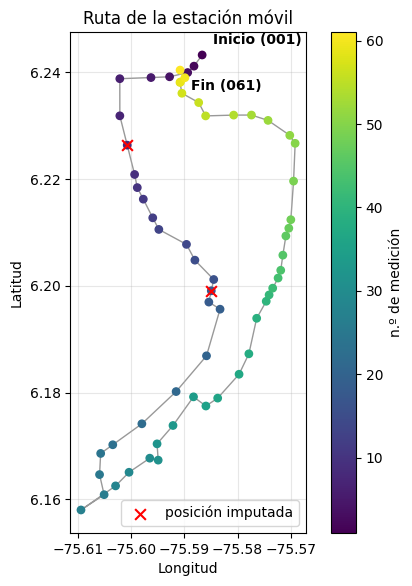

In [36]:
# ── 7. Ruta de la estación móvil ────────────────────────────────────────────
ruta_km   = M.dist_prev_m.sum() / 1000
cierre_m  = haversine(M.lat.iloc[0], M.lon.iloc[0], M.lat.iloc[-1], M.lon.iloc[-1])
dur_min   = (M.hora.iloc[-1] - M.hora.iloc[0]).total_seconds() / 60
ruta = {'inicio': [M.lat.iloc[0], M.lon.iloc[0]], 'fin': [M.lat.iloc[-1], M.lon.iloc[-1]],
        'longitud_km': ruta_km, 'cierre_m': cierre_m, 'duracion_min': dur_min,
        'vel_media_kmh': ruta_km / (dur_min/60) if dur_min > 0 else None,
        'hora_inicio': str(M.hora.iloc[0]), 'hora_fin': str(M.hora.iloc[-1]),
        'alt_min': M.alt.min(), 'alt_max': M.alt.max(),
        'bbox': [M.lat.min(), M.lon.min(), M.lat.max(), M.lon.max()]}
calidad['ruta'] = ruta
print(f"Ruta: {len(M)} puntos, {ruta_km:.1f} km, {dur_min:.0f} min ({f'{ruta['vel_media_kmh']:.0f}' if ruta['vel_media_kmh'] is not None else 'N/A'} km/h medios). "
      f"Inicio→fin separados {cierre_m:.0f} m (circuito {'casi cerrado' if cierre_m < 1000 else 'abierto'}).")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(M.lon, M.lat, '-', color='0.6', lw=1, zorder=1)
sc = ax.scatter(M.lon, M.lat, c=M.orden, cmap='viridis', s=28, zorder=2)
ax.scatter(*M.loc[gps_malo, ['lon', 'lat']].values.T, marker='x', c='r', s=60, label='posición imputada', zorder=3)
ax.annotate('Inicio (001)', (M.lon.iloc[0], M.lat.iloc[0]), xytext=(8, 8), textcoords='offset points', weight='bold')
ax.annotate('Fin (061)',    (M.lon.iloc[-1], M.lat.iloc[-1]), xytext=(8, -14), textcoords='offset points', weight='bold')
plt.colorbar(sc, label='n.º de medición'); ax.set_aspect(1/np.cos(np.radians(M.lat.mean())))
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud'); ax.set_title('Ruta de la estación móvil'); ax.legend(); ax.grid(alpha=.3)
plt.savefig(f'{FIGS}/ruta.png', dpi=140, bbox_inches='tight'); plt.show()

,indicador,Pearson r,p,Spearman ρ,p (S),r parcial (ctrl. tiempo),p (parcial)
0,piso_ruido_dB,0.211,0.103,0.168,0.195,0.096,0.460
1,potencia_media_dB,0.249,0.053,0.130,0.317,0.151,0.244
2,desv_espectro_dB,0.283,0.027,0.281,0.028,0.153,0.238


Temperatura: 42.8–50.4 °C (media 48.2); correlación temperatura–tiempo r = 0.86


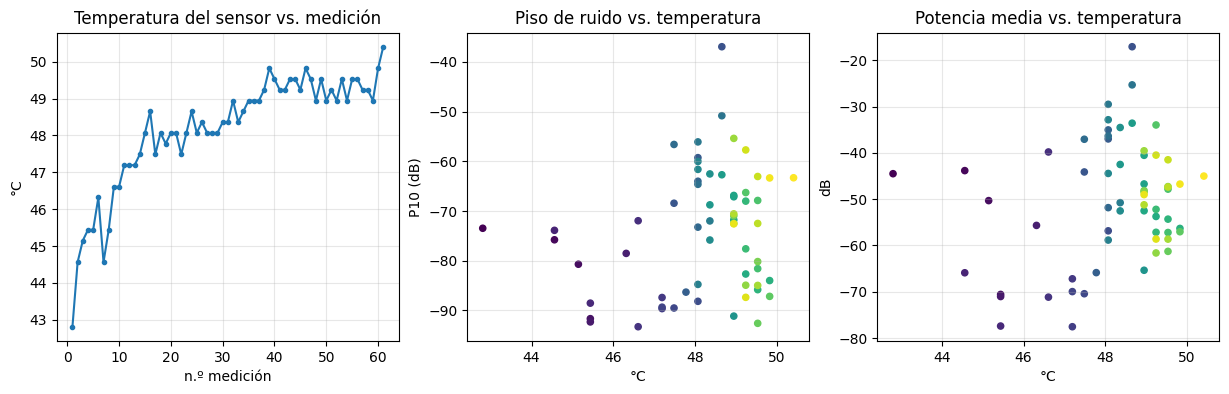

In [37]:
# ── 8. ¿La temperatura del sensor afecta la calidad de la medida? ───────────
# Indicadores de calidad que podrían depender de la temperatura del receptor:
#   · piso de ruido (percentil 10 del espectro): lo que más responde a la deriva térmica del front-end
#   · potencia media y dispersión del espectro
Q = pd.DataFrame({
  'piso_ruido_dB': np.percentile(S_clean, 10, axis=1),
  'potencia_media_dB': 10*np.log10((10**(S_clean/10)).mean(axis=1)),
  'desv_espectro_dB': S_clean.std(axis=1),
})
filas_t = []
for c in Q:
    r_p, p_p = stats.pearsonr(M.temp, Q[c]); r_s, p_s = stats.spearmanr(M.temp, Q[c])
    # correlación parcial controlando el tiempo (la temperatura crece por calentamiento a lo largo de la ruta)
    res = lambda y: y - np.polyval(np.polyfit(M.orden, y, 1), M.orden)
    r_par, p_par = stats.pearsonr(res(M.temp), res(Q[c]))
    filas_t.append((c, r_p, p_p, r_s, p_s, r_par, p_par))
corr_t = pd.DataFrame(filas_t, columns=['indicador', 'Pearson r', 'p', 'Spearman ρ', 'p (S)', 'r parcial (ctrl. tiempo)', 'p (parcial)']).round(3)
display(corr_t)
r_t_orden = stats.pearsonr(M.temp, M.orden)[0]
print(f'Temperatura: {M.temp.min():.1f}–{M.temp.max():.1f} °C (media {M.temp.mean():.1f}); correlación temperatura–tiempo r = {r_t_orden:.2f}')

# criterio: incidencia real solo si persiste al controlar el tiempo (la temperatura y el tiempo/ubicación están confundidos)
sig = corr_t[corr_t['p (parcial)'] < 0.05]
calidad['temperatura'] = {'rango': [M.temp.min(), M.temp.max()], 'r_tiempo': r_t_orden,
                          'tabla': corr_t.to_dict('records'), 'incidencia_significativa': bool(len(sig))}

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(M.orden, M.temp, 'o-', ms=3); ax[0].set_title('Temperatura del sensor vs. medición'); ax[0].set_xlabel('n.º medición'); ax[0].set_ylabel('°C')
ax[1].scatter(M.temp, Q.piso_ruido_dB, c=M.orden, s=20); ax[1].set_title('Piso de ruido vs. temperatura'); ax[1].set_xlabel('°C'); ax[1].set_ylabel('P10 (dB)')
ax[2].scatter(M.temp, Q.potencia_media_dB, c=M.orden, s=20); ax[2].set_title('Potencia media vs. temperatura'); ax[2].set_xlabel('°C'); ax[2].set_ylabel('dB')
for a in ax: a.grid(alpha=.3)
plt.savefig(f'{FIGS}/temperatura.png', dpi=140, bbox_inches='tight'); plt.show()

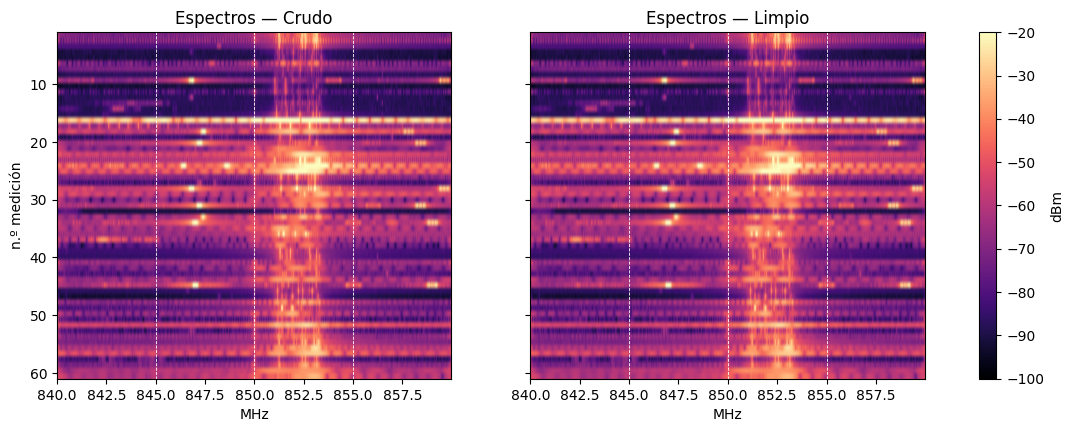

In [38]:
# ── 9. Efecto visual de la limpieza (cascada crudo vs. final) ───────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for a, S, t in zip(ax, [S_raw, S_final], ['Crudo', 'Limpio' + (' + piso' if APLICAR_PISO else '')]):
    im = a.imshow(S, aspect='auto', extent=[FREQ[0], FREQ[-1], len(S), 1], cmap='magma', vmin=-100, vmax=-20)
    a.set_title(f'Espectros — {t}'); a.set_xlabel('MHz')
    for x in (845, 850, 855): a.axvline(x, color='w', lw=.6, ls='--')
ax[0].set_ylabel('n.º medición'); plt.colorbar(im, ax=ax, label='dBm')
plt.savefig(f'{FIGS}/cascada.png', dpi=140, bbox_inches='tight'); plt.show()

In [39]:
# ── 10. LOAD: guardar resultados para los notebooks 2 y 3 ───────────────────
cols = ['orden', 'archivo', 'hora', 'temp', 'lon', 'lat', 'alt', 'hdop', 'gps_imputado', 'saturacion', 'picos_corregidos', 'dist_prev_m']
M[cols].to_csv(f'{OUT}/medidas_limpias.csv', index=False)
np.savez_compressed(f'{OUT}/espectros.npz', S_raw=S_raw, S_clean=S_clean, S_final=S_final, freq=FREQ)
with open(f'{OUT}/calidad.json', 'w') as f:
    json.dump(calidad, f, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print('Guardado en', OUT, '→', os.listdir(OUT))

Guardado en /content/drive/MyDrive/IoT_Examen3/salida → ['figs', 'medidas_limpias.csv', 'espectros.npz', 'calidad.json', 'indicadores_medidas.csv', 'frecuencias.json', 'resumen_canales.csv', 'fuentes.csv', 'informe_tecnico.md', 'informe_tecnico.html']


---
## Parte 2/3 — Indicadores, recomendación e informe

Cubre *"Para los datos transformados en indicadores"* y la **bonificación** (estimación de la fuente por canal).
Usa los resultados generados en la Parte 1 (ya ejecutada en este mismo notebook). Genera `informe_tecnico.md/.html`, `resumen_canales.csv`, `indicadores_medidas.csv`, `fuentes.csv` y figuras.


In [40]:
# ── 1. Entorno y parámetros ────────────────────────────────────────────────
import os, json, base64, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/IoT_Examen3'
except ImportError:
    BASE = os.path.abspath('./IoT_Examen3')
OUT, FIGS = f'{BASE}/salida', f'{BASE}/salida/figs'

UMBRAL_DBM    = -60.0          # canal ocupado/contaminado si la potencia > -60 dBm
MODO_POTENCIA = 'media'        # 'media' = (1/N)·Σ|X_k|²  (potencia media por bin, Parseval discreto)
                               # 'suma'  = Σ|X_k|²        (potencia total integrada del canal: +24 dB sobre 'media' con 256 bins)
USAR_PISO     = True           # True → indicadores con S_final (regla -65→-95 del enunciado); False → S_clean
# criterios del dictamen por canal (% de mediciones ocupadas)
OCUP_RECOMENDADO, OCUP_NO_RECOMENDADO = 25.0, 50.0

M = pd.read_csv(f'{OUT}/medidas_limpias.csv', parse_dates=['hora'])
D = np.load(f'{OUT}/espectros.npz')
S = D['S_final'] if USAR_PISO else D['S_clean']       # espectros para indicadores
S_CLEAN, FREQ = D['S_clean'], D['freq']
calidad = json.load(open(f'{OUT}/calidad.json'))
CANALES = {'A': (840, 845), 'B': (845, 850), 'C': (850, 855), 'D': (855, 860)}
SL = {c: slice(int(np.searchsorted(FREQ, lo - 1e-9)), int(np.searchsorted(FREQ, hi - 1e-9))) for c, (lo, hi) in CANALES.items()}
print({c: (s.stop - s.start) for c, s in SL.items()}, 'bins por canal |', S.shape[0], 'mediciones')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'A': 256, 'B': 256, 'C': 256, 'D': 256} bins por canal | 61 mediciones


In [41]:
# ── 2. Potencia media del canal con Parseval discreto ───────────────────────
# Cada bin ya es |X_k|² en dB → se pasa a lineal (mW), se agrega sobre los bins del canal y se vuelve a dBm.
def potencia_canal(Sx, sl, modo=MODO_POTENCIA):
    lineal = 10 ** (Sx[:, sl] / 10)
    p = lineal.mean(axis=1) if modo == 'media' else lineal.sum(axis=1)
    return 10 * np.log10(p)

P = pd.DataFrame({f'P_{c}': potencia_canal(S, SL[c]) for c in CANALES})           # con los datos de indicadores
Pc = pd.DataFrame({f'P_{c}': potencia_canal(S_CLEAN, SL[c]) for c in CANALES})    # sin piso (para ubicar fuentes)
ocupado = P > UMBRAL_DBM
ind = pd.concat([M[['orden', 'hora', 'lat', 'lon', 'temp']], P, ocupado.add_prefix('ocup_')], axis=1)

def resumen_canales(Sx, modo=MODO_POTENCIA):
    filas = []
    for c in CANALES:
        p = potencia_canal(Sx, SL[c], modo)
        filas.append({'Canal': c, 'Banda (MHz)': f'{CANALES[c][0]}–{CANALES[c][1]}',
                      'Ocupación (% de mediciones > umbral)': 100 * (p > UMBRAL_DBM).mean(),
                      'Potencia media (dBm)': 10 * np.log10((10 ** (p / 10)).mean()),
                      'Mediana (dBm)': np.median(p), 'P90 (dBm)': np.percentile(p, 90), 'Máx (dBm)': p.max(),
                      '% bins > umbral': 100 * (Sx[:, SL[c]] > UMBRAL_DBM).mean()})
    return pd.DataFrame(filas).set_index('Canal')

R = resumen_canales(S)
OC = 'Ocupación (% de mediciones > umbral)'
orden_cont = R.sort_values([OC, 'Potencia media (dBm)'], ascending=False).index.tolist()
R['Ranking (1 = más contaminado)'] = [orden_cont.index(c) + 1 for c in R.index]

# Intervalo de confianza 95 % (Wilson) de la ocupación: con solo 61 mediciones conviene saber qué diferencias son reales
def wilson(k, n, z=1.96):
    p = k / n; den = 1 + z**2 / n
    c = (p + z**2 / (2*n)) / den; h = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / den
    return 100*(c - h), 100*(c + h)
n_med = len(P)
ci = {c: wilson(int(ocupado[f'P_{c}'].sum()), n_med) for c in CANALES}
R['IC95 ocupación (%)'] = [f'{ci[c][0]:.0f}–{ci[c][1]:.0f}' for c in R.index]
display(R.round(1))
canal_max, canal_min = orden_cont[0], orden_cont[-1]
print(f'Más contaminado: Canal {canal_max} | menos contaminado: Canal {canal_min}')

# Sensibilidad: ¿cambia el ranking sin la regla del piso o con la potencia total (suma)?
sens = pd.DataFrame({
  'Ocup. % (indicadores)': R['Ocupación (% de mediciones > umbral)'],
  'Ocup. % sin piso':      resumen_canales(S_CLEAN)['Ocupación (% de mediciones > umbral)'],
  'Ocup. % potencia suma': resumen_canales(S, 'suma')['Ocupación (% de mediciones > umbral)']}).round(1)
display(sens)

,Banda (MHz),Ocupación (% de mediciones > umbral),Potencia media (dBm),Mediana (dBm),P90 (dBm),Máx (dBm),% bins > umbral,Ranking (1 = más contaminado),IC95 ocupación (%)
Canal,,,,,,,,,
A,840–845,24.6,-46.4,-68.1,-54.6,-28.8,21.4,4,16–37
B,845–850,32.8,-37.0,-63.8,-29.2,-26.7,28.5,2,22–45
C,850–855,85.2,-28.2,-46.3,-33.7,-11.3,59.0,1,74–92
D,855–860,29.5,-44.5,-66.5,-42.6,-28.5,25.4,3,20–42


Más contaminado: Canal C | menos contaminado: Canal A


,Ocup. % (indicadores),Ocup. % sin piso,Ocup. % potencia suma
Canal,,,
A,24.6,24.6,90.2
B,32.8,32.8,86.9
C,85.2,85.2,100.0
D,29.5,29.5,82.0


Más contaminada: 853.145 MHz (canal C) — ocupación 90 %, potencia media -26.6 dBm
Menos contaminada: 843.828 MHz (canal A) — ocupación 15 %, potencia media -53.5 dBm


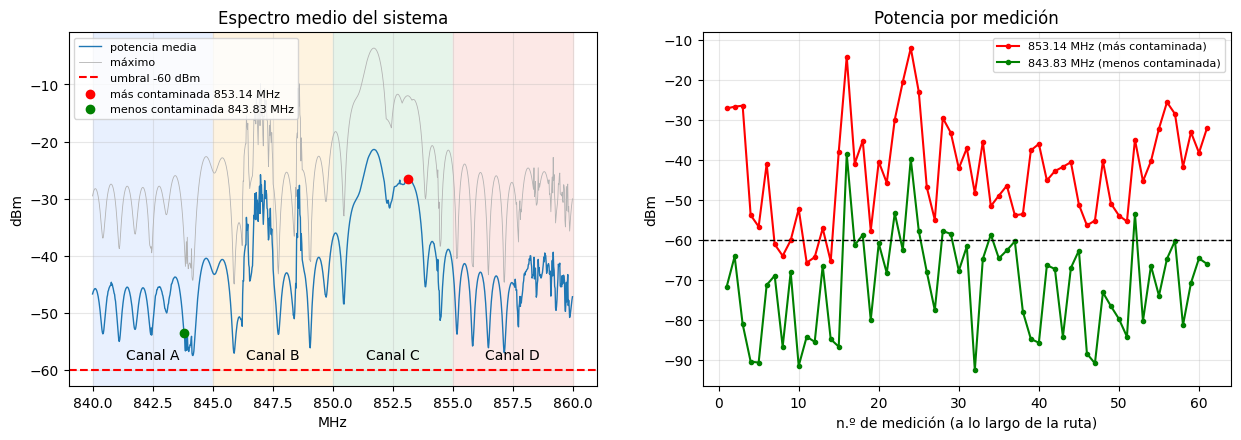

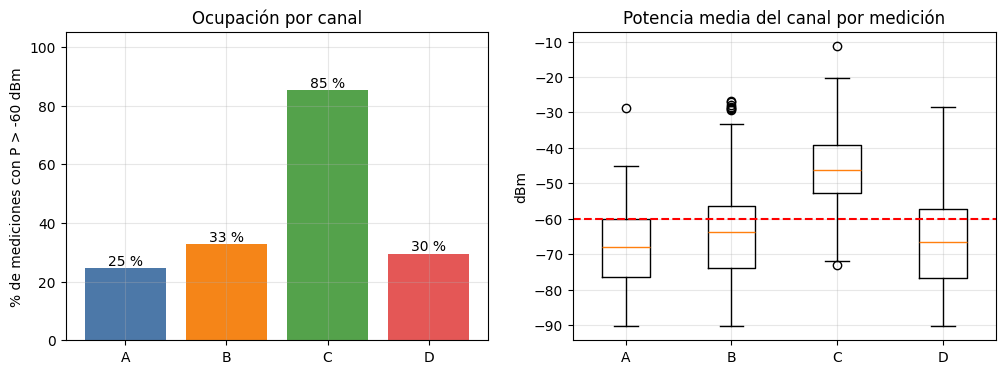

In [42]:
# ── 3. Frecuencia más y menos contaminada de todo el sistema ────────────────
lin = 10 ** (S / 10)
FQ = pd.DataFrame({'f_MHz': FREQ, 'pot_media_dBm': 10 * np.log10(lin.mean(axis=0)),
                   'ocupacion_pct': 100 * (S > UMBRAL_DBM).mean(axis=0), 'max_dBm': S.max(axis=0)})
FQ['canal'] = [next(c for c, sl in SL.items() if sl.start <= i < sl.stop) for i in range(len(FQ))]
rank = FQ.sort_values(['ocupacion_pct', 'pot_media_dBm'], ascending=False)
i_max, i_min = rank.index[0], rank.index[-1]
f_max, f_min = FQ.loc[i_max], FQ.loc[i_min]
print(f'Más contaminada: {f_max.f_MHz:.3f} MHz (canal {f_max.canal}) — ocupación {f_max.ocupacion_pct:.0f} %, potencia media {f_max.pot_media_dBm:.1f} dBm')
print(f'Menos contaminada: {f_min.f_MHz:.3f} MHz (canal {f_min.canal}) — ocupación {f_min.ocupacion_pct:.0f} %, potencia media {f_min.pot_media_dBm:.1f} dBm')

# potencia por medición en esas dos frecuencias (alimenta el mapa de calor del dashboard)
ind['P_fmax'], ind['P_fmin'] = S[:, i_max], S[:, i_min]
ind.to_csv(f'{OUT}/indicadores_medidas.csv', index=False)
json.dump({'f_max_MHz': float(f_max.f_MHz), 'f_min_MHz': float(f_min.f_MHz), 'canal_max_freq': f_max.canal, 'canal_min_freq': f_min.canal,
           'canal_mas_contaminado': canal_max, 'canal_menos_contaminado': canal_min, 'umbral_dBm': UMBRAL_DBM},
          open(f'{OUT}/frecuencias.json', 'w'))

# Gráfica 1: espectro medio del sistema + frecuencia más/menos contaminada
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
ax[0].plot(FQ.f_MHz, FQ.pot_media_dBm, lw=1, label='potencia media')
ax[0].plot(FQ.f_MHz, FQ.max_dBm, lw=.6, color='0.7', label='máximo')
ax[0].axhline(UMBRAL_DBM, color='r', ls='--', label=f'umbral {UMBRAL_DBM:.0f} dBm')
for (lo, hi), c, col in zip(CANALES.values(), CANALES, ['#e8f0fe', '#fef3e0', '#e6f4ea', '#fce8e6']):
    ax[0].axvspan(lo, hi, color=col, zorder=0); ax[0].text((lo + hi) / 2, ax[0].get_ylim()[0] + 2, f'Canal {c}', ha='center')
ax[0].scatter([f_max.f_MHz], [f_max.pot_media_dBm], c='r', zorder=5, label=f'más contaminada {f_max.f_MHz:.2f} MHz')
ax[0].scatter([f_min.f_MHz], [f_min.pot_media_dBm], c='g', zorder=5, label=f'menos contaminada {f_min.f_MHz:.2f} MHz')
ax[0].set_xlabel('MHz'); ax[0].set_ylabel('dBm'); ax[0].set_title('Espectro medio del sistema'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
# Gráfica 2: esa frecuencia a lo largo de la ruta
ax[1].plot(M.orden, S[:, i_max], 'r.-', label=f'{f_max.f_MHz:.2f} MHz (más contaminada)')
ax[1].plot(M.orden, S[:, i_min], 'g.-', label=f'{f_min.f_MHz:.2f} MHz (menos contaminada)')
ax[1].axhline(UMBRAL_DBM, color='k', ls='--', lw=1); ax[1].set_xlabel('n.º de medición (a lo largo de la ruta)'); ax[1].set_ylabel('dBm')
ax[1].set_title('Potencia por medición'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.savefig(f'{FIGS}/frecuencias.png', dpi=140, bbox_inches='tight'); plt.show()

# Gráfica 3: ocupación y distribución de potencia por canal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cols = ['#4c78a8', '#f58518', '#54a24b', '#e45756']
ax[0].bar(R.index, R['Ocupación (% de mediciones > umbral)'], color=cols)
for i, v in enumerate(R['Ocupación (% de mediciones > umbral)']): ax[0].text(i, v + 1, f'{v:.0f} %', ha='center')
ax[0].set_ylabel('% de mediciones con P > -60 dBm'); ax[0].set_title('Ocupación por canal'); ax[0].set_ylim(0, 105)
ax[1].boxplot([P[f'P_{c}'] for c in CANALES]); ax[1].set_xticklabels(list(CANALES)); ax[1].axhline(UMBRAL_DBM, color='r', ls='--')
ax[1].set_ylabel('dBm'); ax[1].set_title('Potencia media del canal por medición')
for a in ax: a.grid(alpha=.3)
plt.savefig(f'{FIGS}/canales.png', dpi=140, bbox_inches='tight'); plt.show()

In [43]:
# ── 4. Dictamen técnico por canal ───────────────────────────────────────────
def dictamen(oc):
    if oc < OCUP_RECOMENDADO:     return 'Recomendado'
    if oc < OCUP_NO_RECOMENDADO:  return 'Condicionado'
    return 'No recomendado'
R['Dictamen'] = R[OC].map(dictamen)
display(R[['Banda (MHz)', OC, 'IC95 ocupación (%)', 'Potencia media (dBm)', 'Dictamen']].round(1))
R.round(1).to_csv(f'{OUT}/resumen_canales.csv')

# ¿Qué canales no se distinguen estadísticamente del menos contaminado? (intervalos de confianza traslapados)
similares = [c for c in R.index if c != canal_min and ci[c][0] <= ci[canal_min][1]]
# Correlación entre canales: si A, B y D suben juntos, parte de la 'contaminación' puede ser común (sobrecarga del receptor)
corr_canales = P.corr().values[np.triu_indices(4, 1)]
print('Canales indistinguibles del menos contaminado:', similares)
print(f'Correlación entre potencias de canal: {corr_canales.min():.2f} – {corr_canales.max():.2f}')

,Banda (MHz),Ocupación (% de mediciones > umbral),IC95 ocupación (%),Potencia media (dBm),Dictamen
Canal,,,,,
A,840–845,24.6,16–37,-46.4,Recomendado
B,845–850,32.8,22–45,-37.0,Condicionado
C,850–855,85.2,74–92,-28.2,No recomendado
D,855–860,29.5,20–42,-44.5,Condicionado


Canales indistinguibles del menos contaminado: ['B', 'D']
Correlación entre potencias de canal: 0.63 – 0.96


,lat,lon,metodo,radio95_m,R2_modelo,n_perdidas,lat_modelo,lon_modelo,dist_a_ruta_m
canal,,,,,,,,,
A,6.2002,-75.5851,centroide ponderado,3325.1881,0.1157,2.0,6.1705,-75.6098,121.9025
B,6.1822,-75.5910,centroide ponderado,1662.1347,0.1492,2.0,6.1687,-75.6062,228.3801
C,6.1953,-75.5882,centroide ponderado,3433.1915,0.1049,2.0,6.1685,-75.6075,357.7626
D,6.1948,-75.5862,centroide ponderado,2572.7635,0.1358,2.0,6.1679,-75.6079,258.5928


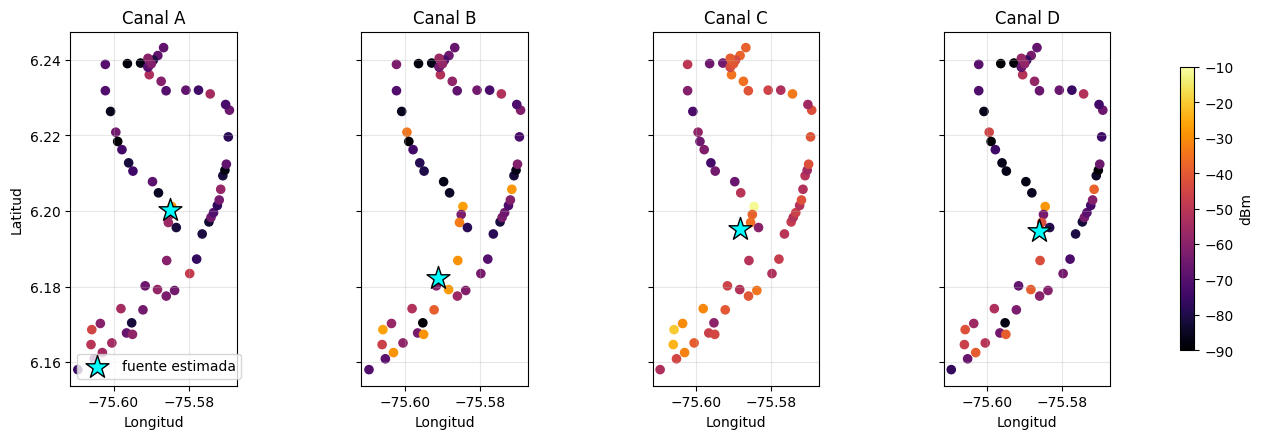

In [44]:
# ── 5. BONIFICACIÓN: estimar la ubicación de la fuente por canal ────────────
# Dos estimadores por canal, sobre la potencia SIN piso (el piso -95 distorsiona el ajuste):
#  (a) Extrapolación con modelo log-distancia  P(d) = 10·log10( 10^((P0 − 10·n·log10 d)/10) + ruido )  ajustado por mínimos cuadrados
#      robustos: (x0, y0, P0, n). La fuente puede quedar fuera de la ruta.
#  (b) Centroide ponderado (potencia lineal) del 10 % de puntos más intensos: estimador robusto sin modelo de propagación.
# Regla: se usa (a) solo si explica los datos (R² ≥ R2_MIN); si no, se usa (b) y se declara la baja confianza.
R2_MIN, D_MIN, MARGEN = 0.5, 30.0, 5000.0
R_T = 6371000.0
lat0, lon0 = M.lat.mean(), M.lon.mean()
to_xy   = lambda lat, lon: (np.radians(lon - lon0) * R_T * np.cos(np.radians(lat0)), np.radians(lat - lat0) * R_T)
from_xy = lambda x, y: (lat0 + np.degrees(y / R_T), lon0 + np.degrees(x / (R_T * np.cos(np.radians(lat0)))))
X, Y = to_xy(M.lat.values, M.lon.values)

def modelo(p, x, y, ruido):
    d = np.maximum(np.hypot(x - p[0], y - p[1]), D_MIN)
    return 10 * np.log10(10 ** ((p[2] - 10 * p[3] * np.log10(d)) / 10) + 10 ** (ruido / 10))

def ajustar(pot, ruido):
    lim = ([X.min() - MARGEN, Y.min() - MARGEN, -100, 2.0], [X.max() + MARGEN, Y.max() + MARGEN, 250, 4.5])
    mejor = None
    for gx in np.linspace(X.min() - 1500, X.max() + 1500, 6):
        for gy in np.linspace(Y.min() - 1500, Y.max() + 1500, 6):
            r = least_squares(lambda p: modelo(p, X, Y, ruido) - pot, [gx, gy, pot.mean() + 90, 3.0], bounds=lim, loss='soft_l1', f_scale=3.0)
            if mejor is None or r.cost < mejor.cost: mejor = r
    return mejor

def centroide(pot, idx):
    top = idx[pot[idx] >= np.percentile(pot[idx], 90)]
    w = 10 ** (pot[top] / 10)
    return (X[top] * w).sum() / w.sum(), (Y[top] * w).sum() / w.sum()

rng = np.random.default_rng(42)
fuentes = []
for c in CANALES:
    pot = Pc[f'P_{c}'].values
    ruido = np.percentile(pot, 5)
    sol = ajustar(pot, ruido); pred = modelo(sol.x, X, Y, ruido)
    r2 = 1 - np.sum((pot - pred) ** 2) / np.sum((pot - pot.mean()) ** 2)
    cx, cy = centroide(pot, np.arange(len(pot)))
    boot = np.array([centroide(pot, rng.integers(0, len(pot), len(pot))) for _ in range(300)])       # incertidumbre por bootstrap
    rad95 = np.percentile(np.hypot(boot[:, 0] - np.median(boot[:, 0]), boot[:, 1] - np.median(boot[:, 1])), 95)
    usar_modelo = r2 >= R2_MIN
    fx, fy = (sol.x[0], sol.x[1]) if usar_modelo else (cx, cy)
    lat_f, lon_f = from_xy(fx, fy); lat_m, lon_m = from_xy(sol.x[0], sol.x[1])
    fuentes.append({'canal': c, 'lat': lat_f, 'lon': lon_f, 'metodo': 'log-distancia' if usar_modelo else 'centroide ponderado',
                    'radio95_m': rad95, 'R2_modelo': r2, 'n_perdidas': sol.x[3], 'lat_modelo': lat_m, 'lon_modelo': lon_m,
                    'dist_a_ruta_m': float(np.min(np.hypot(X - fx, Y - fy)))})
F = pd.DataFrame(fuentes).set_index('canal')
F.to_csv(f'{OUT}/fuentes.csv')
display(F.round(4))

# Mapa rápido: potencia de cada canal a lo largo de la ruta y fuente estimada
fig, ax = plt.subplots(1, 4, figsize=(18, 4.6), sharey=True)
for a, c in zip(ax, CANALES):
    sc = a.scatter(M.lon, M.lat, c=Pc[f'P_{c}'], cmap='inferno', s=35, vmin=-90, vmax=-10)
    a.scatter(F.lon[c], F.lat[c], marker='*', s=300, c='cyan', edgecolors='k', zorder=5, label='fuente estimada')
    a.set_title(f'Canal {c}'); a.set_aspect(1 / np.cos(np.radians(lat0))); a.grid(alpha=.3); a.set_xlabel('Longitud')
ax[0].set_ylabel('Latitud'); ax[0].legend(loc='lower left'); plt.colorbar(sc, ax=ax, label='dBm', shrink=.8)
plt.savefig(f'{FIGS}/fuentes.png', dpi=140, bbox_inches='tight'); plt.show()


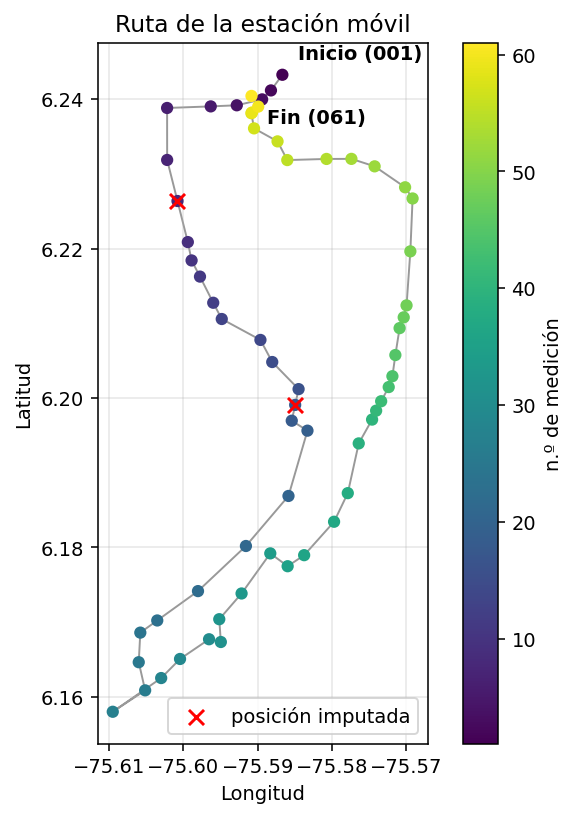
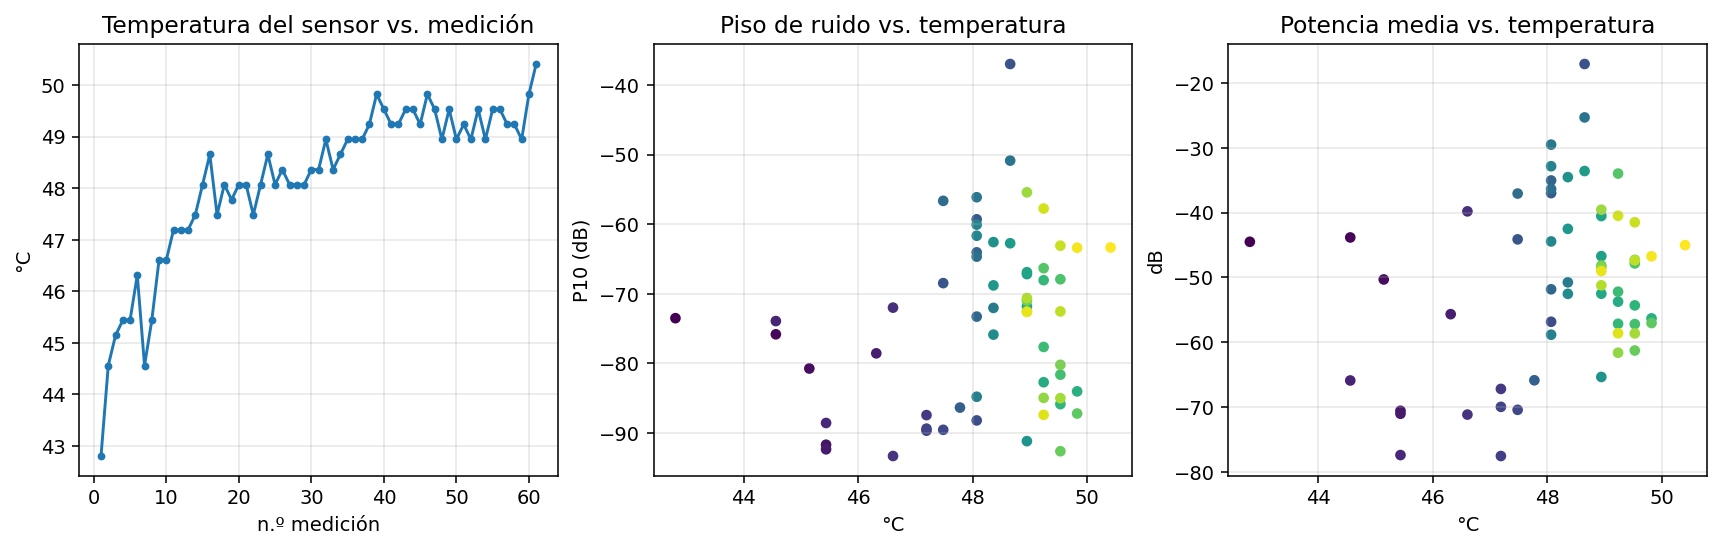
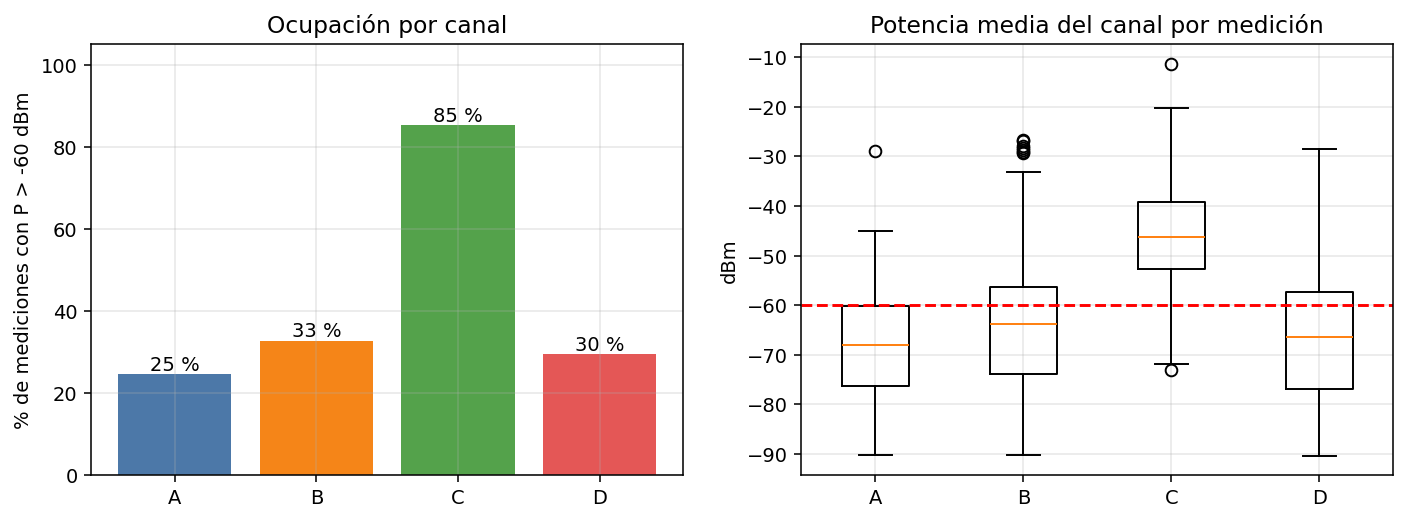
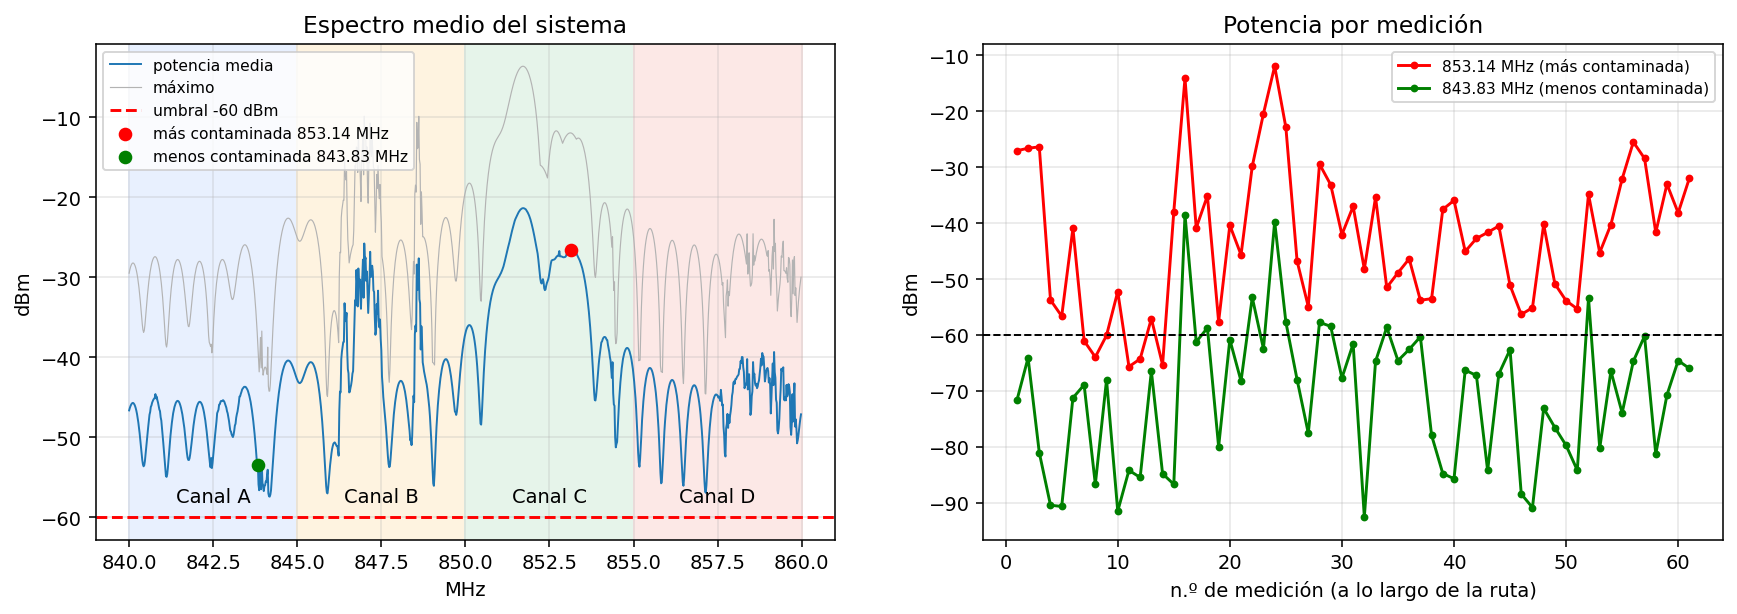
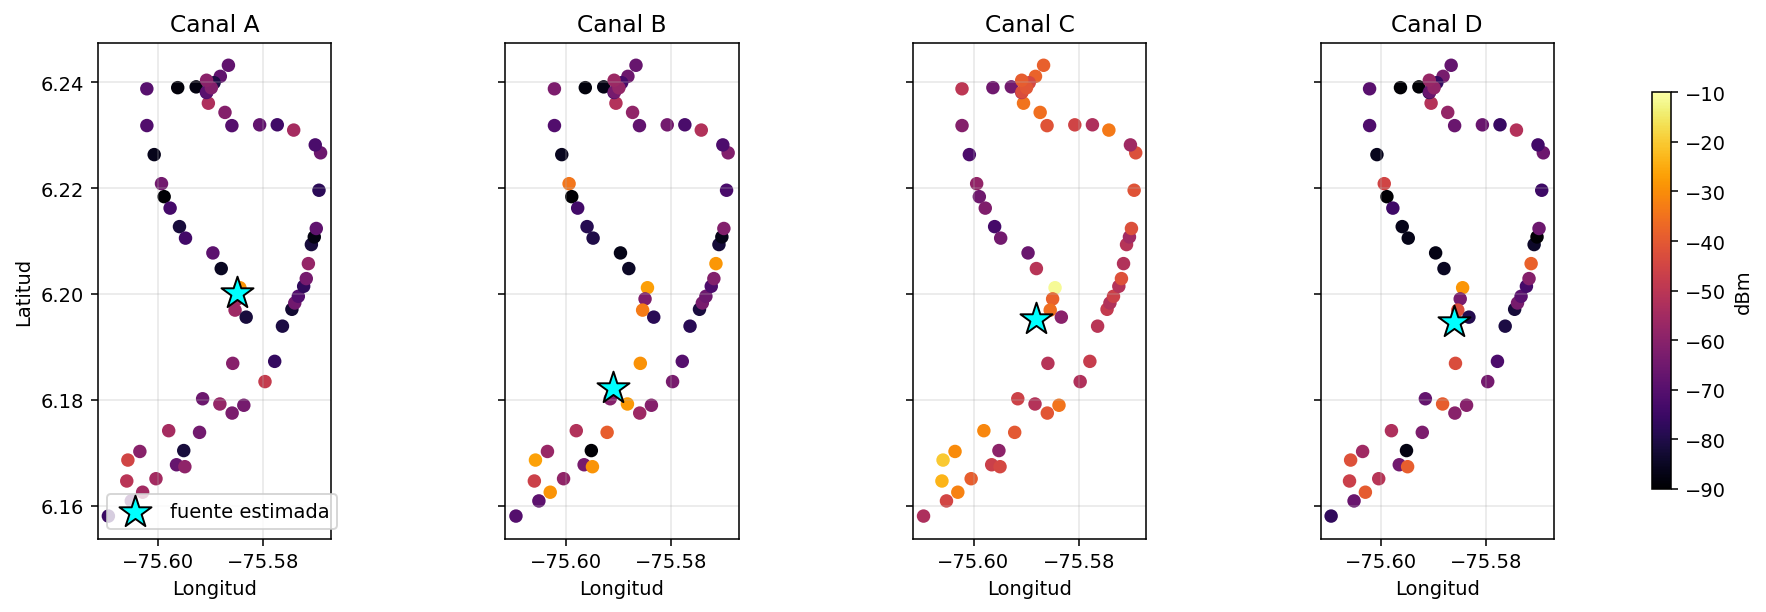

In [45]:
# ── 6. Informe técnico (Markdown + HTML con figuras embebidas) ──────────────
def tabla_md(df, dec=1):
    df = df.copy(); cab = '| ' + ' | '.join(map(str, df.columns)) + ' |\n|' + '---|' * len(df.columns) + '\n'
    filas = ''.join('| ' + ' | '.join(f'{v:.{dec}f}' if isinstance(v, (float, np.floating)) else str(v) for v in r) + ' |\n' for r in df.values)
    return cab + filas

Ft = F.reset_index()[['canal', 'lat', 'lon', 'metodo', 'radio95_m', 'R2_modelo', 'n_perdidas']].copy()
Ft['lat'], Ft['lon'] = Ft.lat.map('{:.5f}'.format), Ft.lon.map('{:.5f}'.format)
Ft['radio95_m'], Ft['R2_modelo'], Ft['n_perdidas'] = Ft.radio95_m.map('{:.0f}'.format), Ft.R2_modelo.map('{:.2f}'.format), Ft.n_perdidas.map('{:.1f}'.format)
q, T = calidad, calidad['temperatura']
chk = pd.DataFrame(q['checks']).rename(columns={'verificacion': 'Verificación', 'casos': 'Casos', 'detalle': 'Detalle'})
imp = pd.DataFrame(q['imputaciones'])
imp.columns = ['Problema', 'Técnica', 'Valores modificados', 'Motivo', '% del total']
ruta = q['ruta']
tr = pd.DataFrame(T['tabla'])[['indicador', 'Pearson r', 'p', 'r parcial (ctrl. tiempo)', 'p (parcial)']]
concl_temp = ('**No se encuentra una incidencia significativa** de la temperatura sobre la calidad de las medidas: las correlaciones brutas son débiles y '
              'la variable está fuertemente confundida con el tiempo (r = %.2f; el sensor se calienta a lo largo del recorrido); al controlar el tiempo desaparecen.' % T['r_tiempo']
              if not T['incidencia_significativa'] else
              '**Existe una incidencia estadísticamente significativa** de la temperatura (persiste al controlar el tiempo) que debe considerarse al comparar mediciones.')

tabla_can = R[['Banda (MHz)', OC, 'IC95 ocupación (%)', 'Potencia media (dBm)', 'Mediana (dBm)', 'P90 (dBm)', 'Dictamen']].reset_index().round(1)
nota_sim = (f'El intervalo de confianza del canal {canal_min} se traslapa con el de {", ".join(similares)}: con {n_med} mediciones esos canales no son estadísticamente distinguibles entre sí; la diferencia significativa es la del canal {canal_max}.' if similares else '')
rec_ok  = [c for c in R.index if R.Dictamen[c] == 'Recomendado']
rec_no  = [c for c in R.index if R.Dictamen[c] == 'No recomendado']
rec_cnd = [c for c in R.index if R.Dictamen[c] == 'Condicionado']
lista = lambda cs: ', '.join(f'Canal {c} ({CANALES[c][0]}–{CANALES[c][1]} MHz)' for c in cs) or 'ninguno'
uso_piso = 'Se aplicó la regla de normalización del enunciado (valores < -65 dB → -95 dB)' if q['aplicar_piso'] else 'No se aplicó la regla de piso de ruido'

md_txt = f'''# Informe técnico — Ocupación del espectro 840–860 MHz, occidente de Medellín
*Internet de las Cosas · Examen/Trabajo 3 · Dirigido a la Agencia Nacional del Espectro (ANE)*

## Resumen ejecutivo
Se analizaron **{q['mediciones_validas']} mediciones** de una estación móvil (banda 840–860 MHz, 1024 bins, resolución ≈ 19.5 kHz) a lo largo de una ruta de {ruta['longitud_km']:.1f} km.
El canal **más contaminado es el {canal_max}** ({CANALES[canal_max][0]}–{CANALES[canal_max][1]} MHz, ocupado en {R[OC][canal_max]:.0f} % de las mediciones) y el **menos contaminado el {canal_min}**
({R[OC][canal_min]:.0f} %). La frecuencia más contaminada del sistema es {f_max.f_MHz:.2f} MHz y la menos contaminada {f_min.f_MHz:.2f} MHz.

## 1. Datos de los sensores
### 1.1 Calidad de los datos
Completitud de espectros: {q['completitud_pct']:.1f} %. Posiciones GPS válidas: {q['gps_valido_pct']:.1f} %.

{tabla_md(chk)}
### 1.2 Imputaciones y correcciones
Valores modificados sin contar la regla de piso: **{q['valores_modificados_sin_piso']}**; con la regla de piso: **{q['valores_modificados_sin_piso'] + (q['valores_modificados_piso'] if q['aplicar_piso'] else 0)}** (de {q['valores_totales_espectro']} valores de espectro). {uso_piso}.

{tabla_md(imp, 3)}
Justificación: el GPS sin fijar (lat = lon = 0) y el HDOP > 5 producen posiciones no confiables y se reconstruyen por interpolación entre vecinos consecutivos; la espiga en 850.000 MHz es un artefacto de fuga del oscilador local de receptores de conversión directa; las espigas aisladas de ≤ 2 bins no corresponden a señales celulares (que ocupan decenas de bins) y se reemplazan por la mediana local. Los espectros con posible saturación ({', '.join(q['saturadas']) or 'ninguno'}) se conservan, marcados.

### 1.3 Ruta de la estación móvil
Inicio en ({ruta['inicio'][0]:.5f}, {ruta['inicio'][1]:.5f}) y fin en ({ruta['fin'][0]:.5f}, {ruta['fin'][1]:.5f}); {ruta['longitud_km']:.1f} km en {ruta['duracion_min']:.0f} min
(≈ {f'{ruta['vel_media_kmh']:.0f}' if ruta['vel_media_kmh'] is not None else 'N/A'} km/h), altitud {ruta['alt_min']:.0f}–{ruta['alt_max']:.0f} m. Inicio y fin distan {ruta['cierre_m']:.0f} m: circuito casi cerrado.

![Ruta](figs/ruta.png)

### 1.4 Incidencia de la temperatura del sensor
Rango observado {T['rango'][0]:.1f}–{T['rango'][1]:.1f} °C.

{tabla_md(tr, 3)}
{concl_temp}

![Temperatura](figs/temperatura.png)

## 2. Indicadores por canal
Potencia media del canal por Parseval discreto: P = (1/N)·Σ|X_k|² sobre los N = 256 bins de cada canal de 5 MHz (modo `{MODO_POTENCIA}`); canal ocupado si P > {UMBRAL_DBM:.0f} dBm.

{tabla_md(tabla_can)}
{nota_sim}

Sensibilidad del ranking (ocupación %):

{tabla_md(sens.reset_index().rename(columns={'canal': 'Canal', 'index': 'Canal'}))}
![Canales](figs/canales.png)

### 2.1 Banda más y menos contaminada
El **Canal {canal_max}** es el más contaminado ({R['Potencia media (dBm)'][canal_max]:.1f} dBm de potencia media) y el **Canal {canal_min}** el menos contaminado ({R['Potencia media (dBm)'][canal_min]:.1f} dBm).
A nivel de frecuencia individual: la más contaminada es **{f_max.f_MHz:.3f} MHz** (ocupada en {f_max.ocupacion_pct:.0f} % de las mediciones; {f_max.pot_media_dBm:.1f} dBm medios) y la menos contaminada **{f_min.f_MHz:.3f} MHz** ({f_min.ocupacion_pct:.0f} %; {f_min.pot_media_dBm:.1f} dBm).

![Frecuencias](figs/frecuencias.png)

### 2.2 Recomendación técnica para la Agencia
Criterio: ocupación < {OCUP_RECOMENDADO:.0f} % → *recomendado*; {OCUP_RECOMENDADO:.0f}–{OCUP_NO_RECOMENDADO:.0f} % → *condicionado*; ≥ {OCUP_NO_RECOMENDADO:.0f} % → *no recomendado*.
- **Recomendados:** {lista(rec_ok)}.
- **Condicionados (requieren coordinación/mitigación):** {lista(rec_cnd)}.
- **No recomendados:** {lista(rec_no)}.

## 3. Bonificación — ubicación estimada de las fuentes
Para cada canal se ajustó un modelo de propagación log-distancia (extrapolación) y, como referencia, el centroide ponderado del 10 % de puntos más intensos. El modelo solo se adopta si explica los datos (R² ≥ {R2_MIN}); en caso contrario se usa el centroide y se declara la baja confianza. Incertidumbre: radio 95 % por bootstrap.

{tabla_md(Ft)}
![Fuentes](figs/fuentes.png)

## 4. Limitaciones
- Los niveles provienen de una captura *max-hold* de 100 espectros sin calibración absoluta documentada (dBFS del receptor); las conclusiones son comparativas entre canales.
- Una sola campaña de ~{ruta['duracion_min']:.0f} min: no captura variación horaria de la ocupación.
- La potencia de los canales A, B y D está muy correlacionada (r entre canales: {corr_canales.min():.2f}–{corr_canales.max():.2f}) y sus picos coinciden con los de C: parte de la contaminación observada puede deberse a sobrecarga/intermodulación del receptor ante señales fuertes (p. ej. la medición saturada {', '.join(q['saturadas']) or 'ninguna'}). Se recomienda repetir con atenuador/filtro pasabanda.
- Estimación de fuentes: el modelo log-distancia explica poca varianza (R² ≤ {F.R2_modelo.max():.2f}) por multitrayecto, múltiples estaciones y captura *max-hold*; las coordenadas son una localización efectiva de baja confianza.
'''
open(f'{OUT}/informe_tecnico.md', 'w').write(md_txt)
import markdown
html = markdown.markdown(md_txt, extensions=['tables'])
html = re.sub(r'src="(figs/[^"]+)"', lambda m: 'src="data:image/png;base64,' + base64.b64encode(open(f'{OUT}/{m.group(1)}', 'rb').read()).decode() + '"', html)
css = '<style>body{font-family:system-ui,sans-serif;max-width:900px;margin:2em auto;line-height:1.5}table{border-collapse:collapse}td,th{border:1px solid #ccc;padding:3px 8px;font-size:.9em}img{max-width:100%}</style>'
open(f'{OUT}/informe_tecnico.html', 'w').write(f'<meta charset="utf-8">{css}{html}')
from IPython.display import HTML, display
display(HTML(css + html))

---
## Parte 3/3 — Dashboard interactivo

Servidor web (**Dash + Plotly**) con: ubicación de las mediciones, ruta, mapas de calor de los canales A–D, mapa de calor de la temperatura del sensor, mapa de calor de la frecuencia más contaminada y (bonificación) fuentes estimadas.
Usa los resultados generados en las partes 1 y 2 (ya ejecutadas en este mismo notebook).

**Cómo verlo:** la celda que lanza el servidor lo muestra *inline* en Colab. Si tu navegador bloquea el iframe, usa `jupyter_mode='tab'`, o la última celda, que exporta `dashboard_estatico.html` (sin servidor).


In [46]:
# ── 1. Dependencias (versiones recientes de Dash y Plotly con mapas MapLibre) ──
!pip install -q -U dash plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 95.9 MB/s eta 0:00:00


In [47]:
# ── 2. Datos y parámetros ──────────────────────────────────────────────────
import os, json
import numpy as np, pandas as pd
import plotly.graph_objects as go
from scipy.spatial import cKDTree
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE, EN_COLAB = '/content/drive/MyDrive/IoT_Examen3', True
except ImportError:
    BASE, EN_COLAB = os.path.abspath('./IoT_Examen3'), False
OUT = f'{BASE}/salida'

IND = pd.read_csv(f'{OUT}/indicadores_medidas.csv', parse_dates=['hora'])
RES = pd.read_csv(f'{OUT}/resumen_canales.csv', index_col='Canal')
FUE = pd.read_csv(f'{OUT}/fuentes.csv', index_col='canal')
FQ  = json.load(open(f'{OUT}/frecuencias.json'))
CANALES = {'A': (840, 845), 'B': (845, 850), 'C': (850, 855), 'D': (855, 860)}

# Capas del dashboard: id → (título, columna, escala de color, unidad, rango)
RANGO_P = (-95, -10)
CAPAS = {'ubicacion': ('Ubicación de las mediciones', None, None, None, None),
         'ruta':      ('Ruta de las mediciones', None, None, None, None)}
for c, (lo, hi) in CANALES.items():
    CAPAS[f'canal_{c}'] = (f'Mapa de calor · Canal {c} ({lo}–{hi} MHz)', f'P_{c}', 'Turbo', 'dBm', RANGO_P)
CAPAS['temp'] = ('Mapa de calor · Temperatura del sensor', 'temp', 'YlOrRd', '°C', (IND.temp.min(), IND.temp.max()))
CAPAS['freq'] = (f"Mapa de calor · Frecuencia más contaminada ({FQ['f_max_MHz']:.3f} MHz)", 'P_fmax', 'Turbo', 'dBm', RANGO_P)
print(len(IND), 'mediciones |', len(CAPAS), 'capas')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
61 mediciones | 8 capas


In [48]:
# ── 3. Malla de interpolación (IDW) → celdas cuadradas para el mapa de calor ─
# Se interpola cada variable sobre una malla de 80 m, solo a ≤ 400 m de la ruta (fuera de ahí no hay datos que respalden el valor).
CELDA_M, BUFFER_M, K_VEC = 80.0, 400.0, 8
R_T = 6371000.0
lat0, lon0 = IND.lat.mean(), IND.lon.mean()
to_xy   = lambda lat, lon: (np.radians(lon - lon0) * R_T * np.cos(np.radians(lat0)), np.radians(lat - lat0) * R_T)
from_xy = lambda x, y: (lat0 + np.degrees(y / R_T), lon0 + np.degrees(x / (R_T * np.cos(np.radians(lat0)))))
X, Y = to_xy(IND.lat.values, IND.lon.values)

gx, gy = np.arange(X.min() - BUFFER_M, X.max() + BUFFER_M, CELDA_M), np.arange(Y.min() - BUFFER_M, Y.max() + BUFFER_M, CELDA_M)
GX, GY = np.meshgrid(gx, gy); celdas = np.c_[GX.ravel(), GY.ravel()]
arbol = cKDTree(np.c_[X, Y])
d1, _ = arbol.query(celdas, k=1)
celdas = celdas[d1 <= BUFFER_M]
d, idx = arbol.query(celdas, k=K_VEC)
pesos = 1.0 / np.maximum(d, 1.0) ** 2; pesos /= pesos.sum(axis=1, keepdims=True)      # pesos IDW (potencia 2)
idw = lambda v: (pesos * np.asarray(v)[idx]).sum(axis=1)

# GeoJSON de celdas (polígonos cuadrados alrededor de cada centro)
h = CELDA_M / 2
def cuadrado(cx, cy):
    esq = [(cx - h, cy - h), (cx + h, cy - h), (cx + h, cy + h), (cx - h, cy + h), (cx - h, cy - h)]
    return [[round(from_xy(x, y)[1], 5), round(from_xy(x, y)[0], 5)] for x, y in esq]   # [lon, lat] (5 decimales ≈ 1 m)
GEO = {'type': 'FeatureCollection', 'features': [
    {'type': 'Feature', 'id': str(i), 'properties': {}, 'geometry': {'type': 'Polygon', 'coordinates': [cuadrado(cx, cy)]}}
    for i, (cx, cy) in enumerate(celdas)]}
IDS = [str(i) for i in range(len(celdas))]
VALORES = {k: idw(IND[col].values) for k, (_, col, *_r) in CAPAS.items() if col}
print(f'{len(celdas)} celdas de {CELDA_M:.0f} m')

2718 celdas de 80 m


In [49]:
# ── 4. Figura del mapa + aplicación Dash ───────────────────────────────────
from dash import Dash, dcc, html, Input, Output

TEXTO_PUNTO = [f'<b>Medición {int(o):03d}</b> · {h_:%H:%M}<br>Temp {t:.1f} °C<br>' + '<br>'.join(f'Canal {c}: {p:.1f} dBm' for c, p in zip('ABCD', ps))
               for o, h_, t, *ps in zip(IND.orden, IND.hora, IND.temp, IND.P_A, IND.P_B, IND.P_C, IND.P_D)]

def crear_figura(capa, overlays=('ruta', 'fuentes')):
    titulo, col, escala, unidad, rango = CAPAS[capa]
    fig = go.Figure()
    if col:                                                               # capa de calor (celdas coloreadas)
        fig.add_trace(go.Choroplethmap(geojson=GEO, locations=IDS, z=VALORES[capa], zmin=rango[0], zmax=rango[1],
                      colorscale=escala, marker_opacity=0.68, marker_line_width=0, hoverinfo='skip', name=titulo,
                      colorbar=dict(title=unidad, thickness=12, len=0.55, x=0.99, xanchor='right', y=0.5)))
    if capa == 'ruta' or 'ruta' in overlays:
        fig.add_trace(go.Scattermap(lat=IND.lat, lon=IND.lon, mode='lines', line=dict(width=3, color='#1b3a4b'), hoverinfo='skip', name='Ruta'))
    if capa == 'ruta':                                                    # puntos numerados en orden de recorrido + inicio/fin
        fig.add_trace(go.Scattermap(lat=IND.lat, lon=IND.lon, mode='markers', name='Mediciones', text=TEXTO_PUNTO, hoverinfo='text',
                      marker=dict(size=9, color=IND.orden, colorscale='Viridis', colorbar=dict(title='n.º', thickness=12, len=0.5, x=0.99, xanchor='right'))))
        fig.add_trace(go.Scattermap(lat=[IND.lat.iloc[0]], lon=[IND.lon.iloc[0]], mode='markers+text', text=['Inicio'], textposition='top right',
                      marker=dict(size=15, color='#1e8e3e'), name='Inicio', hoverinfo='skip'))
        fig.add_trace(go.Scattermap(lat=[IND.lat.iloc[-1]], lon=[IND.lon.iloc[-1]], mode='markers+text', text=['Fin'], textposition='bottom right',
                      marker=dict(size=15, color='#c5221f'), name='Fin', hoverinfo='skip'))
    elif capa == 'ubicacion' or 'puntos' in overlays:                     # ubicación de cada medición
        fig.add_trace(go.Scattermap(lat=IND.lat, lon=IND.lon, mode='markers', name='Mediciones', text=TEXTO_PUNTO, hoverinfo='text',
                      marker=dict(size=9, color='#0b6e8a')))
    if 'fuentes' in overlays:                                             # bonificación: fuente estimada por canal
        fig.add_trace(go.Scattermap(lat=FUE.lat, lon=FUE.lon, mode='markers+text', text=[f'Fuente {c}' for c in FUE.index], textposition='top center',
                      marker=dict(size=16, color='#ffffff'), name='Fuente estimada', hoverinfo='text',
                      hovertext=[f'Canal {c}: {r.lat:.5f}, {r.lon:.5f}<br>{r.metodo} · incertidumbre ±{r.radio95_m:.0f} m' for c, r in FUE.iterrows()]))
        fig.add_trace(go.Scattermap(lat=FUE.lat, lon=FUE.lon, mode='markers', marker=dict(size=9, color='#c5221f'), showlegend=False, hoverinfo='skip'))
    fig.update_layout(map=dict(style='open-street-map', center=dict(lat=lat0, lon=lon0), zoom=11.7), margin=dict(l=0, r=0, t=0, b=0),
                      legend=dict(orientation='h', y=0.01, x=0.01, bgcolor='rgba(255,255,255,.8)'), uirevision=capa, height=640)
    return fig

# ── Panel de indicadores (tabla + barras de ocupación) ──
COLOR_DICT = {'Recomendado': '#1e8e3e', 'Condicionado': '#b06000', 'No recomendado': '#c5221f'}
def panel_indicadores():
    oc = 'Ocupación (% de mediciones > umbral)'
    barras = go.Figure(go.Bar(x=list(RES.index), y=RES[oc], marker_color=[COLOR_DICT[d] for d in RES.Dictamen], text=[f'{v:.0f} %' for v in RES[oc]], textposition='outside'))
    barras.update_layout(height=230, margin=dict(l=30, r=10, t=30, b=25), yaxis=dict(range=[0, 105], title='% ocupación'), title=dict(text=f"Ocupación (P > {FQ['umbral_dBm']:.0f} dBm)", font=dict(size=13)), plot_bgcolor='white')
    filas = [html.Tr([html.Th(t) for t in ['Canal', 'MHz', 'Pot. media', 'Dictamen']])] + [
        html.Tr([html.Td(c), html.Td(r['Banda (MHz)']), html.Td(f"{r['Potencia media (dBm)']:.1f} dBm"),
                 html.Td(r.Dictamen, style={'color': COLOR_DICT[r.Dictamen], 'fontWeight': 600})]) for c, r in RES.iterrows()]
    return [dcc.Graph(figure=barras, config={'displayModeBar': False}), html.Table(filas, style={'width': '100%', 'fontSize': 13, 'borderCollapse': 'collapse'})]

# ── Aplicación ──
app = Dash(__name__, title='Ocupación 840–860 MHz · Medellín')
PANEL = {'background': 'white', 'border': '1px solid #d5dbe1', 'borderRadius': 6, 'padding': 12}
app.layout = html.Div(style={'fontFamily': 'system-ui, -apple-system, Segoe UI, sans-serif', 'background': '#eef1f4', 'padding': 14, 'color': '#14202b'}, children=[
    html.Div([html.H2('Ocupación del espectro 840–860 MHz · occidente de Medellín', style={'margin': 0, 'fontSize': 21}),
              html.Div(f"{len(IND)} mediciones · canal más contaminado: {FQ['canal_mas_contaminado']} · menos contaminado: {FQ['canal_menos_contaminado']} · frecuencia más contaminada: {FQ['f_max_MHz']:.3f} MHz",
                       style={'fontSize': 13, 'color': '#4a5a68', 'marginTop': 3})], style={'marginBottom': 10}),
    html.Div(style={'display': 'grid', 'gridTemplateColumns': '230px 1fr 290px', 'gap': 12, 'alignItems': 'start'}, children=[
        html.Div(style=PANEL, children=[
            html.Div('Capa', style={'fontWeight': 600, 'marginBottom': 6}),
            dcc.RadioItems(id='capa', value='canal_C', options=[{'label': v[0], 'value': k} for k, v in CAPAS.items()], labelStyle={'display': 'block', 'margin': '5px 0', 'fontSize': 13}),
            html.Hr(),
            html.Div('Superponer', style={'fontWeight': 600, 'marginBottom': 6}),
            dcc.Checklist(id='overlays', value=['ruta', 'fuentes'], labelStyle={'display': 'block', 'margin': '5px 0', 'fontSize': 13},
                          options=[{'label': 'Ruta', 'value': 'ruta'}, {'label': 'Puntos de medición', 'value': 'puntos'}, {'label': 'Fuentes estimadas (bonificación)', 'value': 'fuentes'}]),
            html.Div('Los mapas de calor son interpolaciones IDW a ≤ 400 m de la ruta.', style={'fontSize': 11, 'color': '#5c6b78', 'marginTop': 10})]),
        html.Div(style=PANEL, children=[dcc.Graph(id='mapa', style={'height': 640}, config={'scrollZoom': True})]),
        html.Div(style=PANEL, children=panel_indicadores()),
    ]),
])

@app.callback(Output('mapa', 'figure'), Input('capa', 'value'), Input('overlays', 'value'))
def actualizar(capa, overlays):
    return crear_figura(capa, tuple(overlays or ()))

# Lanzar el servidor: en Colab se muestra dentro de la propia celda
if EN_COLAB:
    app.run(jupyter_mode='inline', jupyter_height=780, port=8050, debug=False)   # alternativas: 'tab' (nueva pestaña) o 'external'
else:
    app.run(debug=False, port=8050)

<IPython.core.display.Javascript object>